In [1]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt


In [2]:
DATASET_PATH = "data/raw"

CLASSES = [
    "belly_pain",
    "burping",
    "discomfort",
    "hungry",
    "tired"
]


In [3]:
def compute_mel_fixed(
    filepath,
    sr=22050,
    n_mels=128,
    n_fft=2048,
    hop_length=512,
    max_frames=300
):
    y, sr = librosa.load(filepath, sr=sr, mono=True)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Pad or truncate to fixed length
    if mel_db.shape[1] < max_frames:
        pad_width = max_frames - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode="constant")
    else:
        mel_db = mel_db[:, :max_frames]

    return mel_db


In [4]:
class_mel_spectrograms = {}

for class_name in CLASSES:
    class_path = os.path.join(DATASET_PATH, class_name)

    mel_list = []

    for file in os.listdir(class_path):
        if file.endswith(".wav"):
            filepath = os.path.join(class_path, file)
            mel = compute_mel_fixed(filepath)
            mel_list.append(mel)

    # Average over all files in the class
    class_mel_spectrograms[class_name] = np.mean(
        np.stack(mel_list), axis=0
    )

    print(f"{class_name}: {len(mel_list)} files used")


belly_pain: 16 files used
burping: 8 files used
discomfort: 27 files used
hungry: 382 files used
tired: 24 files used


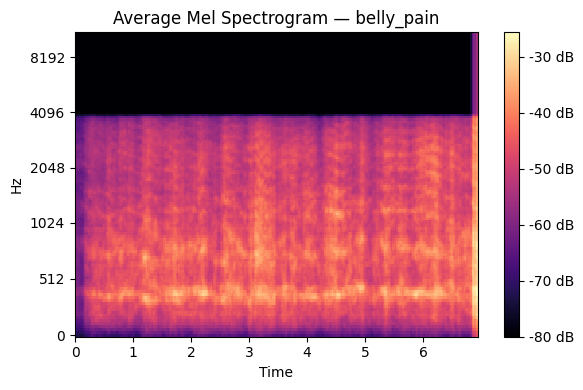

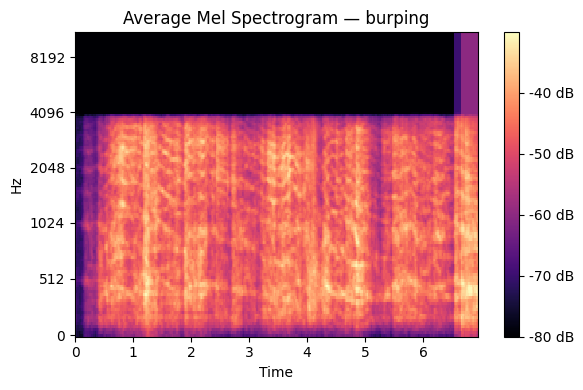

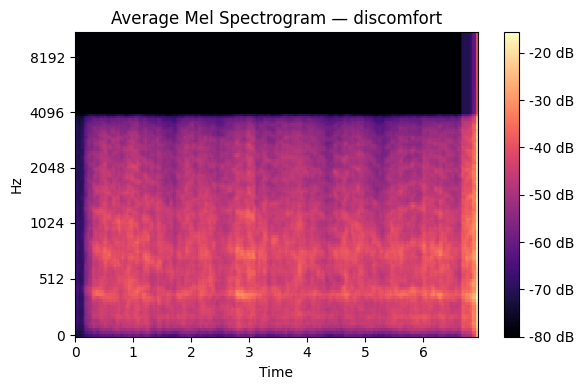

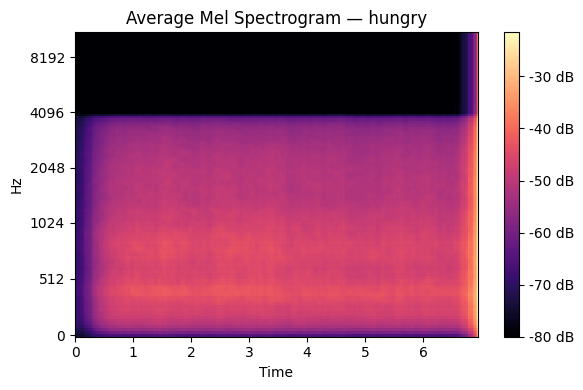

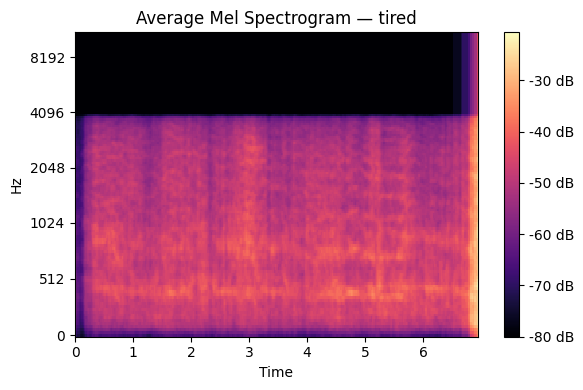

In [5]:
for class_name, mel_avg in class_mel_spectrograms.items():
    plt.figure(figsize=(6, 4))

    librosa.display.specshow(
        mel_avg,
        sr=22050,
        hop_length=512,
        x_axis="time",
        y_axis="mel"
    )

    plt.colorbar(format="%+2.0f dB")
    plt.title(f"Average Mel Spectrogram — {class_name}")
    plt.tight_layout()
    plt.show()
